Эмпирическая матрица переходов :
                A         C         G         T
  A   0.36580   0.15282   0.14567   0.33572
  C   0.39703   0.16914   0.15608   0.27774
  G   0.32134   0.22829   0.14826   0.30211
  T   0.28267   0.15558   0.18645   0.37530

max|P_emp - P| = 0.02002


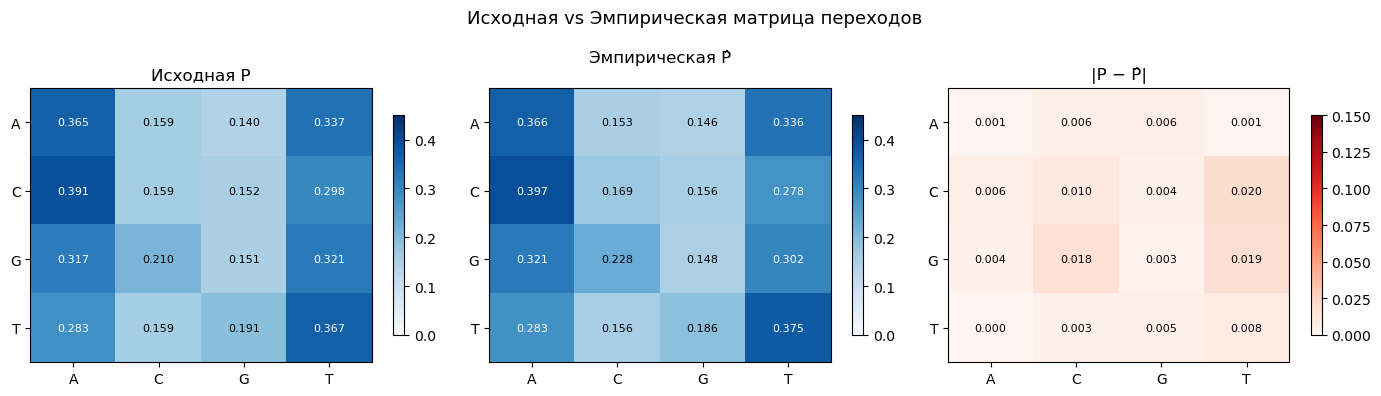

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
%matplotlib inline
 
NUCLEOTIDES = ["A", "C", "G", "T"]
NUC2IDX     = {n: i for i, n in enumerate(NUCLEOTIDES)}
FASTA_PATH  = "436.fasta.fa"
seq_parts = []
with open(FASTA_PATH) as f:
    for line in f:
        line = line.strip()
        if not line.startswith(">"):
            seq_parts.append(line.upper())
seq = "".join(seq_parts)
dinuc = np.zeros((4,4), dtype=int)
for k in range(len(seq)-1):
    a, b = seq[k], seq[k+1]
    if a in NUC2IDX and b in NUC2IDX:
        dinuc[NUC2IDX[a], NUC2IDX[b]] += 1
P = dinuc / dinuc.sum(axis=1, keepdims=True)
evals, evecs = np.linalg.eig(P.T)
idx = np.argmin(np.abs(evals - 1.0))
pi  = evecs[:, idx].real; pi /= pi.sum()

def generate_sequence(P, length, start_state, rng):
    states = [start_state]
    cur    = start_state
    for _ in range(length - 1):
        cur = int(rng.choice(4, p=P[cur]))
        states.append(cur)
    return states
 
rng        = np.random.default_rng(seed=42)
N_SEQS     = 10
SEQ_LEN    = 1000
emp_dinuc  = np.zeros((4, 4))
 
for i in range(N_SEQS):
    start  = int(rng.choice(4, p=pi))
    states = generate_sequence(P, SEQ_LEN, start, rng)
    for k in range(len(states)-1):
        emp_dinuc[states[k], states[k+1]] += 1
 
P_emp = emp_dinuc / emp_dinuc.sum(axis=1, keepdims=True)
print("Эмпирическая матрица переходов :")
print("         " + "  ".join(f"{n:>8}" for n in NUCLEOTIDES))
for i, ni in enumerate(NUCLEOTIDES):
    print(f"  {ni}  " + "  ".join(f"{P_emp[i,j]:>8.5f}" for j in range(4)))
print(f"\nmax|P_emp - P| = {np.max(np.abs(P_emp - P)):.5f}")
 
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
vmin, vmax = 0.0, 0.45
for ax, mat, title in zip(axes,
    [P, P_emp, np.abs(P - P_emp)],
    ["Исходная P", "Эмпирическая P̂\n", "|P − P̂|"]):
    vm = (0, 0.15) if "разница" in title or "−" in title else (vmin, vmax)
    im = ax.imshow(mat, cmap="Blues" if "−" not in title else "Reds",
                   vmin=vm[0], vmax=vm[1], aspect="auto")
    ax.set_xticks(range(4)); ax.set_xticklabels(NUCLEOTIDES)
    ax.set_yticks(range(4)); ax.set_yticklabels(NUCLEOTIDES)
    ax.set_title(title, fontsize=12)
    plt.colorbar(im, ax=ax, shrink=0.8)
    for i in range(4):
        for j in range(4):
            ax.text(j, i, f"{mat[i,j]:.3f}", ha="center", va="center",
                    fontsize=8, color="white" if mat[i,j] > vm[1]*0.6 else "black")
 
fig.suptitle("Исходная vs Эмпирическая матрица переходов", fontsize=13)
plt.tight_layout()
plt.show()

'''
10 последовательностей по 1000 нт, сгенерированных по матрице P, воспроизводят исходное распределение переходов 
с точностью 0.020. Расхождение объясняется малым объёмом выборки. 
Структура матрицы сохранена.
'''